In [25]:
# Import des bibliothèques nécessaires pour le traitement des données,
# l'entraînement du modèle et l'évaluation des métriques.
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve, 
    average_precision_score
)



In [26]:
# Chargement des données prétraitées depuis le dossier clean_data.
# y_train et y_test sont convertis en vecteurs 1D avec squeeze().
X_train = pd.read_csv("../clean_data/X_train.csv")
X_test = pd.read_csv("../clean_data/X_test.csv")
y_train = pd.read_csv("../clean_data/y_train.csv").squeeze()
y_test = pd.read_csv("../clean_data/y_test.csv").squeeze()


In [27]:
# Encodage des variables temporelles en composantes sin/cos pour conserver la cyclicité.
X_train["Month_sin"] = np.sin(2 * np.pi * X_train["Month"] / 12)
X_train["Month_cos"] = np.cos(2 * np.pi * X_train["Month"] / 12)

X_test["Month_sin"] = np.sin(2 * np.pi * X_test["Month"] / 12)
X_test["Month_cos"] = np.cos(2 * np.pi * X_test["Month"] / 12)

# Encodage de la variable "Day" en variables sin et cos.
X_train["Day_sin"] = np.sin(2 * np.pi * X_train["Day"] / 31)
X_train["Day_cos"] = np.cos(2 * np.pi * X_train["Day"] / 31)

X_test["Day_sin"] = np.sin(2 * np.pi * X_test["Day"] / 31)
X_test["Day_cos"] = np.cos(2 * np.pi * X_test["Day"] / 31)

# Suppression des colonnes d'origine après encodage.
X_train = X_train.drop(columns=["Month", "Day"])
X_test = X_test.drop(columns=["Month", "Day"])

In [28]:
# Standardisation des caractéristiques pour améliorer la convergence du réseau.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
# Conversion des ensembles de features et labels en tenseurs PyTorch.
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


In [30]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [31]:
# Création des DataLoaders pour itérer sur les mini-batchs pendant l'entraînement
# et l'évaluation.
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [32]:

# Définition de l'architecture du perceptron multi-couche.
# Le réseau prend en entrée un vecteur de taille input_size et produit un logit.
class MLP_V2(nn.Module):

    def __init__(self,
                 input_size=45,
                 hidden_sizes=[64, 32, 16],
                 lr=0.0001,
                 dropout=0.5,
                 weight_decay=0.001
                 ):

        super().__init__()

        layers = []

        in_features = input_size

        for hidden in hidden_sizes:

            layers.append(nn.Linear(in_features, hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

            in_features = hidden

        layers.append(nn.Linear(in_features, 1))

        self.network = nn.Sequential(*layers)


    def forward(self, x):        return self.network(x)
        # Retourne le logit brut avant la fonction sigmoïde.

In [33]:
# Instanciation du modèle avec une architecture simple.
model = MLP_V2(
    input_size=45,
    hidden_sizes=[64],
    lr=0.0001,
    dropout=0.5,
    weight_decay=0.001
)


In [34]:
# Gestion du déséquilibre de classes avec un poids positif pour la perte.
fraud = y_train.sum()

normal = len(y_train) - fraud

ratio = normal / fraud

pos_weight = torch.tensor(
    [ratio],
    dtype=torch.float32
)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

# Optimiseur et scheduler pour l'entraînement.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6)

In [35]:
class EarlyStopping:
    def __init__(
        self,
        patience=5,
        min_delta=0.0,
        path="best_model.pth",
        verbose=True
    ):

        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.verbose = verbose

        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False

    def __call__(self, val_loss, model):

        # La validation s'améliore
        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

            torch.save(model.state_dict(), self.path)

            if self.verbose:
                print(f"✓ Nouveau meilleur modèle sauvegardé "
                      f"(Val Loss = {val_loss:.4f})")

        else:

            self.counter += 1

            if self.verbose:
                print(
                    f"Aucune amélioration "
                    f"({self.counter}/{self.patience})"
                )

            if self.counter >= self.patience:
                self.early_stop = True

In [36]:
# Fonction d'entraînement pour une époque.
# Met à jour les poids du modèle sur chaque mini-batch.
def train_one_epoch(model, train_loader, criterion, optimizer):

    model.train()

    running_loss = 0.0

    train_bar = tqdm(train_loader, leave=False)

    for batch_idx, (X_batch, y_batch) in enumerate(train_bar):

        optimizer.zero_grad()

        outputs = model(X_batch)

        y_batch = y_batch.unsqueeze(1)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        train_bar.set_postfix(
            loss=f"{running_loss/(batch_idx+1):.4f}"
        )

    epoch_loss = running_loss / len(train_loader)

    return epoch_loss



In [37]:
# Fonction d'évaluation du modèle sur l'ensemble de test/validation.
# Retourne la perte et les métriques classiques.
def evaluate(model, test_loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            outputs = model(X_batch)

            y_batch = y_batch.unsqueeze(1)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities >= 0.5).float()

            all_labels.extend(
                y_batch.cpu().numpy().flatten()
            )

            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy().flatten()
            )

    validation_loss = running_loss / len(test_loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        all_labels,
        all_probabilities
    )

    return {
        "loss": validation_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,

        "roc_auc": roc_auc    }

In [38]:
# Fonction de boucle d'entraînement complète sur plusieurs époques.
# Elle enregistre l'historique des métriques et gère le scheduler / early stopping.
def fit(
    model,
    train_loader,
    test_loader,
    criterion,
    optimizer,
    epochs=50,
    scheduler=None,
    early_stopping=None
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "roc_auc": []
    }

    for epoch in range(epochs):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        metrics = evaluate(
            model,
            test_loader,
            criterion
        )
     
        if scheduler is not None:
             scheduler.step(metrics["loss"])

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Learning Rate: {current_lr:.6f}")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(metrics["loss"])
        history["accuracy"].append(metrics["accuracy"])
        history["precision"].append(metrics["precision"])
        history["recall"].append(metrics["recall"])
        history["f1"].append(metrics["f1"])
        history["roc_auc"].append(metrics["roc_auc"])

        if early_stopping is not None:

            early_stopping(metrics["loss"], model)

            if early_stopping.early_stop:
                print("\nEarly stopping déclenché.")
                break

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {metrics['loss']:.4f} | "
            f"Accuracy: {metrics['accuracy']:.4f} | "
            f"Precision: {metrics['precision']:.4f} | "
            f"Recall: {metrics['recall']:.4f} | "
            f"F1: {metrics['f1']:.4f} | "
            f"ROC-AUC: {metrics['roc_auc']:.4f}"
        )

    return history

In [39]:
early_stopping = EarlyStopping(
    patience=5,
    min_delta=0.001,
    path="best_model.pth"
)

In [40]:
history = fit(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    epochs=50,
    optimizer=optimizer,
    scheduler=scheduler,
    early_stopping=early_stopping
)

model.load_state_dict(
    torch.load("best_model.pth")
)

  0%|          | 0/625 [00:00<?, ?it/s]

Learning Rate: 0.000100
✓ Nouveau meilleur modèle sauvegardé (Val Loss = 1.3235)
Epoch [1/50] | LR: 0.000100 | Train Loss: 1.3374 | Val Loss: 1.3235 | Accuracy: 0.5647 | Precision: 0.0517 | Recall: 0.4598 | F1: 0.0929 | ROC-AUC: 0.5100


  0%|          | 0/625 [00:00<?, ?it/s]

Learning Rate: 0.000100
✓ Nouveau meilleur modèle sauvegardé (Val Loss = 1.3156)
Epoch [2/50] | LR: 0.000100 | Train Loss: 1.3278 | Val Loss: 1.3156 | Accuracy: 0.5602 | Precision: 0.0530 | Recall: 0.4784 | F1: 0.0954 | ROC-AUC: 0.5329


  0%|          | 0/625 [00:00<?, ?it/s]

...

  0%|          | 0/625 [00:00<?, ?it/s]

Learning Rate: 0.000100
Aucune amélioration (4/5)
Epoch [17/50] | LR: 0.000100 | Train Loss: 1.2708 | Val Loss: 1.2934 | Accuracy: 0.5864 | Precision: 0.0617 | Recall: 0.5299 | F1: 0.1105 | ROC-AUC: 0.5902


  0%|          | 0/625 [00:00<?, ?it/s]

Learning Rate: 0.000100
Aucune amélioration (5/5)

Early stopping déclenché.


<All keys matched successfully>

In [41]:
# Fonction de prédiction pour générer les labels et probabilités à partir d'un modèle entraîné.
def predict(model, data_loader, threshold=0.5):

    model.eval()

    y_true = []
    y_proba = []
    y_pred = []

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            # Forward
            outputs = model(X_batch)

            # Logits -> Probabilités
            probabilities = torch.sigmoid(outputs)

            # Probabilités -> Classes
            predictions = (probabilities >= threshold).float()

            # Sauvegarde
            y_true.extend(y_batch.cpu().numpy())

            y_proba.extend(probabilities.cpu().numpy().flatten())

            y_pred.extend(predictions.cpu().numpy().flatten())

    return y_true, y_proba, y_pred

In [42]:
## Évaluation du modèle
print("=" * 50)
print("Évaluation du modèle MLP sur l'ensemble de test ")
print("=" * 50)
y_true, y_proba, y_pred = predict(model, test_loader)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")

Évaluation du modèle MLP sur l'ensemble de test 
Accuracy : 0.5898
Precision : 0.0614
Recall : 0.5216
F1-score : 0.1098
ROC-AUC : 0.5892


In [43]:
##Exporter les métriques dans un fichier texte pour une analyse ultérieure.

metrics = pd.DataFrame({
    "Modèle": ["MLP(Pytorch)"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred, pos_label=1)],
    "Recall": [recall_score(y_test, y_pred, pos_label=1)],
    "F1-score": [f1_score(y_test, y_pred, pos_label=1)],
    "ROC-AUC": [roc_auc_score(y_test, y_pred)]
})

metrics.to_csv("../results/MLP_metrics.csv", index=False)

PRESENTATION DES RESULTATS


<Figure size 800x600 with 0 Axes>

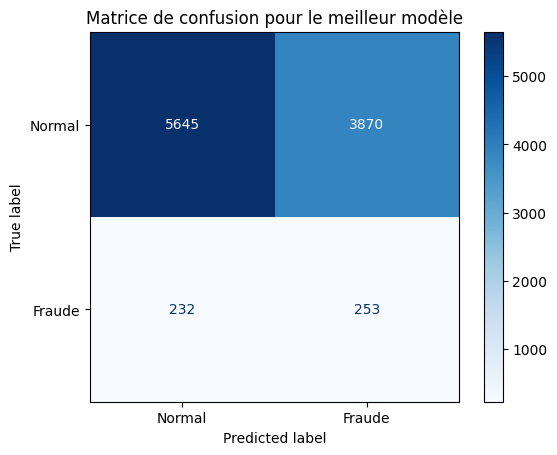

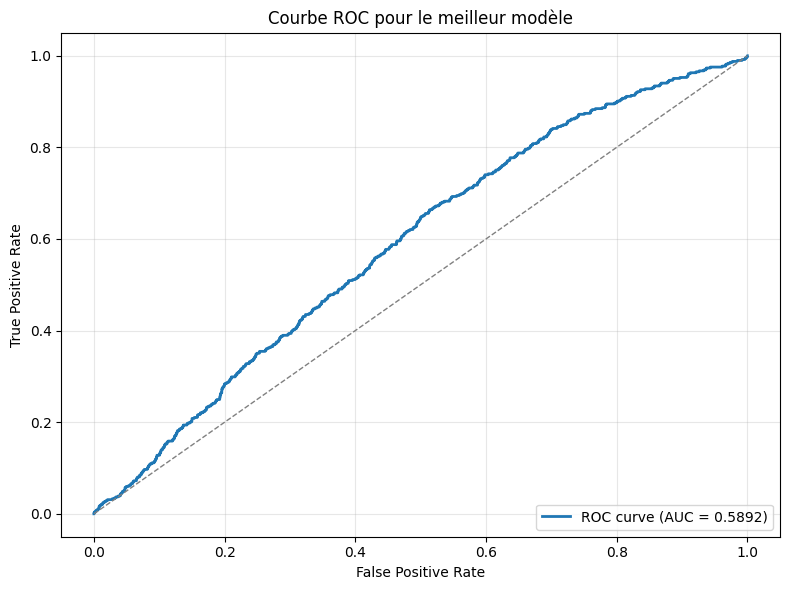

ROC AUC: 0.5892


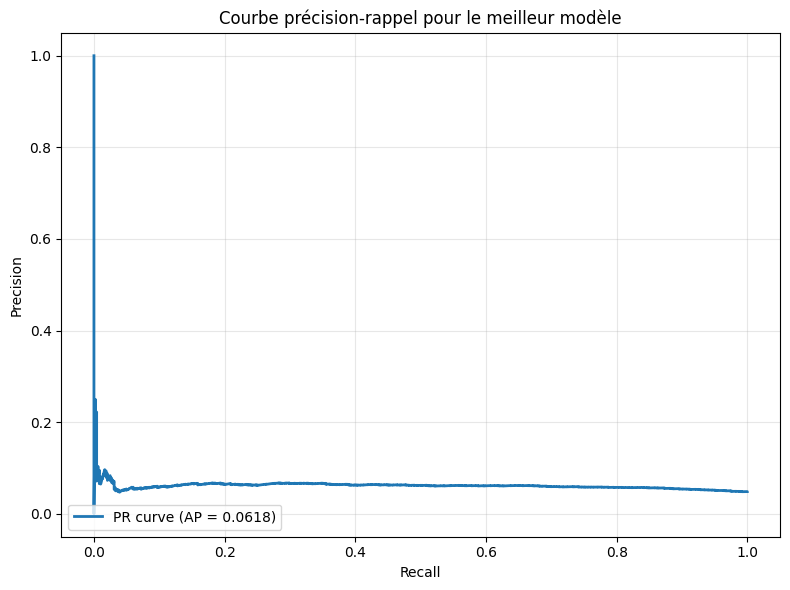

Average Precision (AP): 0.0618


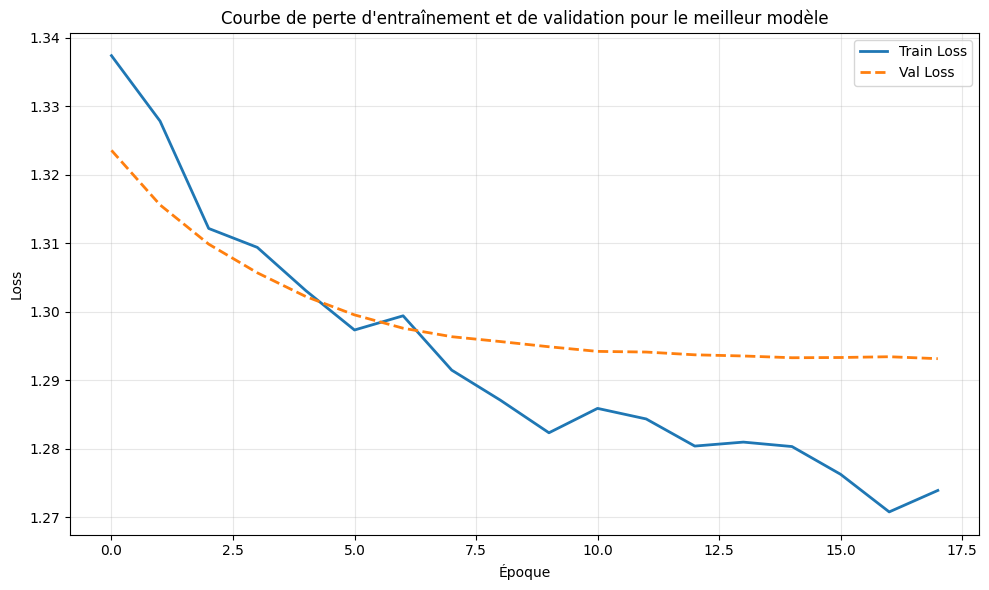

In [44]:
print("=" * 60)
print("PRESENTATION DES RESULTATS")
print("=" * 60)

# Le notebook ne définit pas `runner`, donc on crée un objet local
# pour utiliser le meilleur modèle sauvegardé et l'historique d'entraînement.
if not os.path.exists("best_model.pth"):
    raise ValueError("Aucun meilleur modèle n'a été trouvé. Exécutez les expériences d'abord.")

class SimpleRunner:
    def __init__(self, model, history):
        self.best_model = model
        self.best_history = history

# Recharge explicitement le meilleur état sauvegardé
model.load_state_dict(torch.load("best_model.pth"))
runner = SimpleRunner(model=model, history=history)

# Prédictions sur l'ensemble de test
# Utilise la meilleure version de modèle sélectionnée par le runner
best_model = runner.best_model

# Assurez-vous que la fonction predict est définie dans le notebook
try:
    y_true, y_proba, y_pred = predict(best_model, test_loader)
except NameError:
    raise NameError("La fonction 'predict' n'est pas définie. Ajoutez-la avant de tracer la courbe ROC.")

# Matrice de confusion pour le meilleur modèle
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraude"]
)
plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues")
plt.title("Matrice de confusion pour le meilleur modèle")
plt.show()

# Calcul des métriques ROC
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = roc_auc_score(y_true, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC pour le meilleur modèle")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

# Tracer la courbe de précision-rappel pour le meilleur modèle
precision, recall, _ = precision_recall_curve(y_true, y_proba)
average_precision = average_precision_score(y_true, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR curve (AP = {average_precision:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe précision-rappel pour le meilleur modèle")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {average_precision:.4f}")

# Tracer la courbe de perte d'entraînement et de validation pour le meilleur modèle
if runner.best_history is None:
    raise ValueError("Aucun historique de meilleur modèle disponible. Exécutez les expériences d'abord.")

history_best = runner.best_history
plt.figure(figsize=(10, 6))
plt.plot(history_best["train_loss"], label="Train Loss", linewidth=2)
plt.plot(history_best["val_loss"], label="Val Loss", linestyle="--", linewidth=2)
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Courbe de perte d'entraînement et de validation pour le meilleur modèle")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

